In [1]:
import numpy as np

EMBEDDINGS_PATH = '../data/raw/item_embeddings.npz'
embeddings_data = np.load(EMBEDDINGS_PATH)

print("Ключи в файле:", embeddings_data.files)
items = embeddings_data['item_id']
vectors = embeddings_data['embedding']

print(f"\nВсего объектов: {len(items):,}")
print(f"Размерность одного вектора: {vectors.shape[1]}")

# 3. Посмотрим на первый элемент
print("\n--- Пример данных для первого видео ---")
print(f"ID видео (item_id): {items[0]}")
print(f"Вектор: {vectors[0]}")
print(f"Тип данных: {vectors.dtype}")

print(30*'-')
print("\n--- Пример данных для первого видео ---")
print(f"ID видео (item_id): {items[1]}")
print(f"Вектор: {vectors[1]}")
print(f"Тип данных: {vectors.dtype}")

Ключи в файле: ['item_id', 'embedding']

Всего объектов: 19,627,601
Размерность одного вектора: 64

--- Пример данных для первого видео ---
ID видео (item_id): 38
Вектор: [-0.09326    0.08154   -0.09674    0.01052    0.02841   -0.2266
 -0.0379     0.05203    0.0309    -0.02333    0.00031   -0.004257
  0.02249   -0.00794    0.02946   -0.01235   -0.0847     0.010155
  0.004826   0.06384    0.1868    -0.01047    0.0777    -0.02959
 -0.07874   -0.0635    -0.004124   0.2462     0.1741    -0.05182
  0.1698     0.04462    0.0002866  0.1051    -0.1569    -0.1838
 -0.1613     0.1211     0.1493    -0.08105   -0.05768    0.03397
 -0.03967    0.2207    -0.09125   -0.1367     0.0752     0.1175
  0.1188     0.1433    -0.00387   -0.0266     0.08105   -0.004147
 -0.128      0.1393    -0.1437     0.1306    -0.2389    -0.1144
  0.1367    -0.0783    -0.04846    0.00932  ]
Тип данных: float16
------------------------------

--- Пример данных для первого видео ---
ID видео (item_id): 62
Вектор: [-0.2335   

In [2]:
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import gc

n_clusters = 200

train_size = 500000
np.random.seed(42)
sample_indices = np.random.choice(len(vectors), train_size, replace=False)
vectors_sample = vectors[sample_indices].astype('float32')

print(f"Обучаем KMeans на {train_size} примерах...")

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans.fit(vectors_sample)

del vectors_sample
gc.collect()

print("Присваиваем кластеры всем видео...")
all_clusters = kmeans.predict(vectors.astype('float32'))

item_clusters = pd.DataFrame({
    'item_id': items,
    'video_cluster': all_clusters
})

print("Готово! Пример распределения видео по кластерам:")
print(item_clusters['video_cluster'].value_counts().head(10))

Обучаем KMeans на 500000 примерах...
Присваиваем кластеры всем видео...
Готово! Пример распределения видео по кластерам:
video_cluster
45     172918
101    167243
57     165911
180    165514
58     163400
48     155690
15     152834
128    148712
179    148611
41     147703
Name: count, dtype: int64


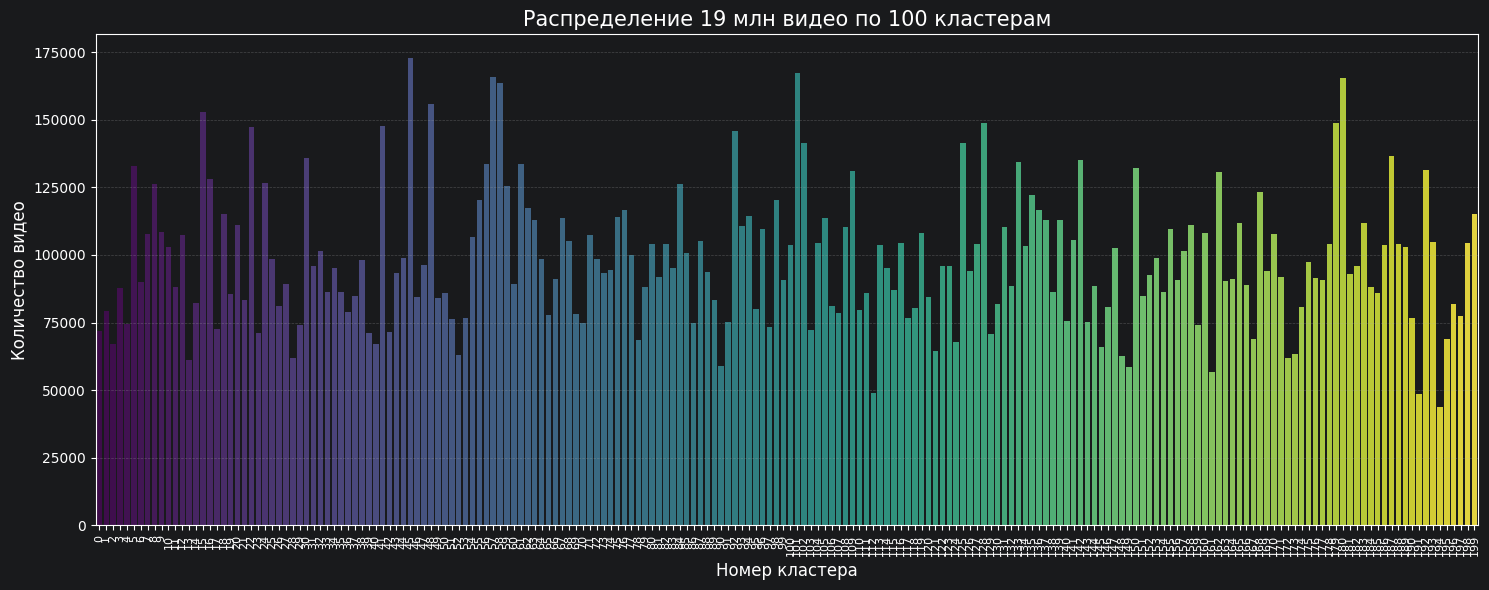

Минимум видео в кластере: 43,801
Максимум видео в кластере: 172,918
Разница между макс и мин: 129,117


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

cluster_counts = item_clusters['video_cluster'].value_counts().sort_index()

plt.figure(figsize=(15, 6))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values,
    hue=cluster_counts.index,
    palette='viridis',
    legend=False
)

plt.title('Распределение 19 млн видео по 100 кластерам', fontsize=15)
plt.xlabel('Номер кластера', fontsize=12)
plt.ylabel('Количество видео', fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout() # Чтобы всё влезло красиво
plt.show()

# 3. Статистика
print(f"Минимум видео в кластере: {cluster_counts.min():,}")
print(f"Максимум видео в кластере: {cluster_counts.max():,}")
print(f"Разница между макс и мин: {cluster_counts.max() - cluster_counts.min():,}")

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import gc

df = pd.read_parquet('../data/processed/train_features.parquet')

drop_cols = [
    'user_id', 'author_id', 'target', 'timespent',
    'train_interactions_rank_x', 'train_interactions_rank_y',
    'author_mean_target', 'user_mean_target'
]
features = [c for c in df.columns if c not in drop_cols]

df_sample = df.sample(n=5000000, random_state=42)
y = df_sample['target'].values
X = df_sample[features].copy()

del df
del df_sample
gc.collect()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
del X
gc.collect()

def add_clusters(target_df, clusters_df):
    relevant_ids = target_df['item_id'].unique()
    mini_clusters = clusters_df[clusters_df['item_id'].isin(relevant_ids)].copy()
    mini_clusters['video_cluster'] = mini_clusters['video_cluster'].astype('int16')

    new_df = target_df.merge(mini_clusters, on='item_id', how='left')

    if new_df['video_cluster'].isnull().any():
        new_df['video_cluster'] = new_df['video_cluster'].fillna(-1).astype('int16')

    del mini_clusters
    gc.collect()
    return new_df

print("Добавляем базовые кластеры...")
X_train = add_clusters(X_train, item_clusters)
X_test = add_clusters(X_test, item_clusters)

print("Генерация продвинутых признаков...")

cluster_performance = X_train.assign(target=y_train).groupby('video_cluster')['target'].mean().to_dict()

X_train['cluster_avg_ratio'] = X_train['video_cluster'].map(cluster_performance).astype('float32')
X_test['cluster_avg_ratio'] = X_test['video_cluster'].map(cluster_performance).astype('float32')

global_mean = y_train.mean()
X_test['cluster_avg_ratio'] = X_test['cluster_avg_ratio'].fillna(global_mean)

if 'avg_target' in X_train.columns:
    X_train['cluster_vs_user_diff'] = X_train['cluster_avg_ratio'] - X_train['avg_target']
    X_test['cluster_vs_user_diff'] = X_test['cluster_avg_ratio'] - X_test['avg_target']

cluster_duration = X_train.groupby('video_cluster')['duration'].mean().to_dict()
X_train['cluster_avg_duration'] = X_train['video_cluster'].map(cluster_duration).astype('float32')
X_test['cluster_avg_duration'] = X_test['video_cluster'].map(cluster_duration).astype('float32')


print(f"X_train: {X_train.shape[0]:,} строк, {X_train.shape[1]} колонок")
print(f"Новые колонки: ['cluster_avg_ratio', 'cluster_vs_user_diff', 'cluster_avg_duration']")
print(f"Память X_train: {X_train.memory_usage().sum() / 1024**2:.2f} MB")

gc.collect()

Добавляем базовые кластеры...
Генерация продвинутых признаков...

--- Итог после генерации фич ---
X_train: 4,000,000 строк, 27 колонок
Новые колонки: ['cluster_avg_ratio', 'cluster_vs_user_diff', 'cluster_avg_duration']
Память X_train: 568.39 MB


0

In [5]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

model_lgb_final = lgb.LGBMRegressor(
    n_estimators=1200,
    learning_rate=0.05,
    max_depth=10,
    num_leaves=64,
    random_state=42,
    n_jobs=-1,
    importance_type='gain'
)

print("Запуск финального обучения...")
model_lgb_final.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

Запуск финального обучения...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.133829 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3268
[LightGBM] [Info] Number of data points in the train set: 4000000, number of used features: 27
[LightGBM] [Info] Start training from score 0.526714
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1200]	valid_0's l1: 0.297425	valid_0's l2: 0.120579


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,10
,learning_rate,0.05
,n_estimators,1200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [6]:
y_pred_final = np.clip(model_lgb_final.predict(X_test), 0, 1)

mae_final = mean_absolute_error(y_test, y_pred_final)
r2_final = r2_score(y_test, y_pred_final)

print(f"Старый MAЕ: 0.2988 | НОВЫЙ MAE: {mae_final:.5f}")
print(f"Старый R2:  0.2711 | НОВЫЙ R2:  {r2_final:.5f}")

improvement = (0.2988 - mae_final) / 0.2988 * 100
print(f"Улучшение MAE: {improvement:.4f}%")


--- СРАВНЕНИЕ РЕЗУЛЬТАТОВ ---
Старый MAЕ: 0.2988 | НОВЫЙ MAE: 0.29734
Старый R2:  0.2711 | НОВЫЙ R2:  0.27504
Улучшение MAE: 0.4885%


C:\Users\kioto\AppData\Local\Temp\ipykernel_16164\3536438921.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Value", y="Feature", data=feature_imp.head(15), palette='rocket')


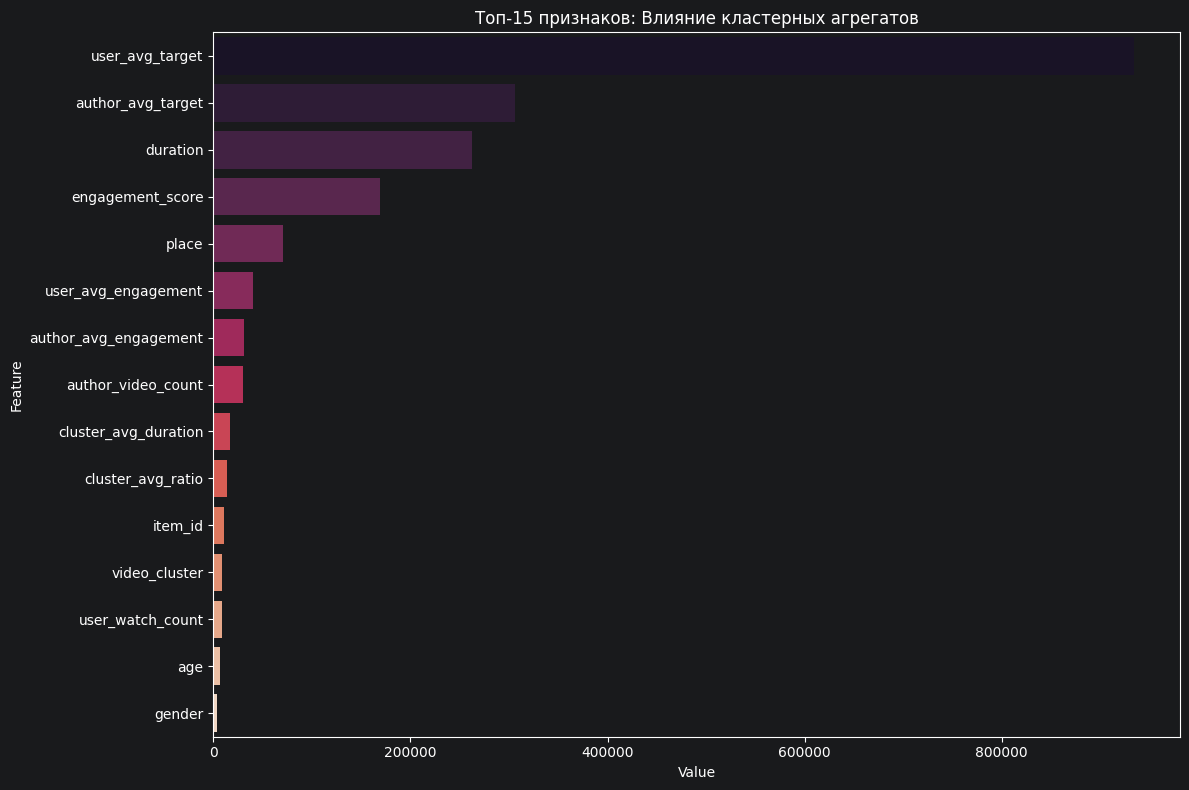

Признак 'cluster_avg_ratio' занял 10-е место.
Признак 'cluster_avg_duration' занял 9-е место.


In [7]:
feature_imp = pd.DataFrame({'Value': model_lgb_final.feature_importances_, 'Feature': X_train.columns})
feature_imp = feature_imp.sort_values(by="Value", ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x="Value", y="Feature", data=feature_imp.head(15), palette='rocket')
plt.title('Топ-15 признаков: Влияние кластерных агрегатов')
plt.tight_layout()
plt.show()

for col in ['cluster_avg_ratio', 'cluster_vs_user_diff', 'cluster_avg_duration']:
    if col in feature_imp['Feature'].values:
        rank = feature_imp.reset_index(drop=True)[feature_imp.reset_index(drop=True)['Feature'] == col].index[0] + 1
        print(f"Признак '{col}' занял {rank}-е место.")

In [8]:
import numpy as np

y_pred_final = model_lgb_final.predict(X_test)
y_pred_final = np.clip(y_pred_final, 0, 1)

comparison_df = pd.DataFrame({
    'Real_Ratio': y_test,
    'Predicted_Ratio': y_pred_final,
    'Duration_Sec': X_test['duration'].values
})

comparison_df['Real_Seconds'] = (comparison_df['Real_Ratio'] * comparison_df['Duration_Sec']).round(2)
comparison_df['Predicted_Seconds'] = (comparison_df['Predicted_Ratio'] * comparison_df['Duration_Sec']).round(2)

comparison_df['Error_Seconds'] = (comparison_df['Real_Seconds'] - comparison_df['Predicted_Seconds']).abs().round(2)

print("Сравнение времени просмотра на обогащенных данных (в секундах):")
display(comparison_df[['Duration_Sec', 'Real_Seconds', 'Predicted_Seconds', 'Error_Seconds']].head(10))

mean_error_sec_final = comparison_df['Error_Seconds'].mean()
print(f"\nИтоговая средняя ошибка: {mean_error_sec_final:.2f} секунд")

Сравнение времени просмотра на обогащенных данных (в секундах):


,Duration_Sec,Real_Seconds,Predicted_Seconds,Error_Seconds
0,52,52.0,34.76,17.24
1,45,5.0,9.65,4.65
2,73,17.0,22.34,5.34
3,60,1.0,39.06,38.06
4,16,7.0,10.34,3.34
5,59,20.0,33.89,13.89
6,57,3.0,12.62,9.62
7,46,1.0,3.78,2.78
8,70,4.0,18.48,14.48
9,15,1.0,10.01,9.01



Итоговая средняя ошибка: 14.96 секунд
